# Fair Lending Project - Seattle University


Data Modeling - Combine Datasets (SBA,FRED, CENSUS) for analytics

In [9]:
import pandas as pd
import numpy as np
import sqlite3
import os
import requests
import matplotlib.pyplot as plt
import seaborn as sns




## Environment Setup

In [10]:

sba_project_db_path = '../data/sba_loans.db'
sba_loan_db_url = 'https://www.dropbox.com/scl/fi/wbv3d7rekx9l638y18nxq/sba_loans.db?rlkey=n66u91ete4q6jdwfnm8fuis48&st=kvf78bsm&dl=1'

db_fred_path = '../data/fred_indicators.db'
db_census_path = '../data/sba_census.db'

db_census_url = 'https://www.dropbox.com/scl/fi/n3kq9j0cmncf05l1r8y12/sba_census.db?rlkey=1weab5lkylssqnb71xb47tlay&dl=1'
db_fred_url = 'https://www.dropbox.com/scl/fi/73whajs6vtycejpjut8s9/fred_indicators.db?rlkey=2x1caljfbt7h60b9nai8x14vq&dl=1'


#Cache data locally if not already present
if not os.path.exists(sba_project_db_path):
    print("Downloading sba_loans.db ...")
    response = requests.get(sba_loan_db_url)
    response.raise_for_status()
    with open(sba_project_db_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded sba_loans.db.")
else:
    print("sba_loans.db already exists.")
if not os.path.exists(db_fred_path):
    print("Downloading fred_indicators.db ...")
    response = requests.get(db_fred_url)
    response.raise_for_status()
    with open(db_fred_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded fred_indicators.db")
else:
    print("fred_indicators.db already exists.")

if not os.path.exists(db_census_path):
    print("Downloading sba_census.db ...")
    response = requests.get(db_census_url)
    response.raise_for_status()
    with open(db_census_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded sba_census.db.")
else:
    print("sba_census.db already exists.")

sba_loans.db already exists.
fred_indicators.db already exists.
sba_census.db already exists.


## Load Data

In [11]:
conn = sqlite3.connect(sba_project_db_path)
df_sba_loan = pd.read_sql_query("SELECT * FROM V_SBA_LOAN", conn)
conn.close()

print(f"Loaded {len(df_sba_loan)} loans data from the SQL View.")

Loaded 886649 loans data from the SQL View.


In [12]:
df_sba_loan.head()

,loan_id,naics_2digit,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,low_doc,gross_approved,sba_approved,disbursement_gross,is_default,sector_text
0,1000014003,45,IN,1997,84,4,2.0,0,N,Y,60000.0,48000.0,60000.0,0,44-45
1,1000024006,72,IN,1997,60,2,2.0,0,N,Y,40000.0,32000.0,40000.0,0,72
2,1000034009,62,IN,1997,180,7,1.0,0,N,N,287000.0,215250.0,287000.0,0,62
3,1000044001,0,OK,1997,60,2,1.0,0,N,Y,35000.0,28000.0,35000.0,0,99
4,1000054004,0,FL,1997,240,14,1.0,0,N,N,229000.0,229000.0,229000.0,0,99


In [13]:
df_sba_loan.describe(include='all')

,loan_id,naics_2digit,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,low_doc,gross_approved,sba_approved,disbursement_gross,is_default,sector_text
count,8.866490e+05,886649,886637,886649.000000,886649.000000,886649.000000,885505.000000,886649.000000,609394,880650,8.866490e+05,8.866490e+05,8.866490e+05,886649.000000,886649
unique,NaN,25,51,NaN,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,21
top,NaN,0,CA,NaN,NaN,NaN,NaN,NaN,N,N,NaN,NaN,NaN,NaN,99
freq,NaN,191150,129355,NaN,NaN,NaN,NaN,NaN,408763,770479,NaN,NaN,NaN,NaN,191150
mean,4.800955e+09,NaN,NaN,2001.351242,110.093821,11.224500,1.282059,0.766257,NaN,NaN,1.929663e+05,1.493405e+05,2.016339e+05,0.172033,NaN
std,2.533611e+09,NaN,NaN,5.609874,78.443072,73.059293,0.450002,0.645050,NaN,NaN,2.846444e+05,2.294018e+05,2.890607e+05,0.377409,NaN
min,1.000014e+09,NaN,NaN,1987.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,1.000000e+03,5.000000e+02,4.000000e+03,0.000000,NaN
25%,2.632785e+09,NaN,NaN,1997.000000,60.000000,2.000000,1.000000,0.000000,NaN,NaN,3.500000e+04,2.125000e+04,4.192700e+04,0.000000,NaN
50%,4.401324e+09,NaN,NaN,2003.000000,84.000000,4.000000,1.000000,1.000000,NaN,NaN,9.000000e+04,6.000000e+04,1.000000e+05,0.000000,NaN
75%,6.942864e+09,NaN,NaN,2006.000000,120.000000,10.000000,2.000000,1.000000,NaN,NaN,2.250000e+05,1.736000e+05,2.374020e+05,0.000000,NaN


In [14]:
conn = sqlite3.connect(db_census_path)
df_census_segment_avg = pd.read_sql_query("SELECT * FROM V_CENSUS_BUSINESS_SEGMENTS", conn)
conn.close()

print(f"Loaded {len(df_census_segment_avg)} industry-state segments from the SQL View.")


Loaded 1020 industry-state segments from the SQL View.


In [15]:
df_census_segment_avg.describe(include='all')

,State_Code,Sector,avg_pct_women,avg_pct_minority,avg_pct_vet,avg_rev_per_firm,avg_emp_per_firm
count,1020,1020,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
unique,51,20,NaN,NaN,NaN,NaN,NaN
top,AK,11,NaN,NaN,NaN,NaN,NaN
freq,20,51,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.416468,3.719163,1.885385,2960.043533,10.126065
std,NaN,NaN,0.574359,0.518920,0.281354,6140.423940,17.689971
min,NaN,NaN,0.151322,1.012314,0.483221,0.000000,0.000000
25%,NaN,NaN,1.006409,3.711499,1.883090,221.600577,1.812823
50%,NaN,NaN,1.425688,3.863994,1.935766,627.716244,5.180650
75%,NaN,NaN,1.895437,3.979050,1.978571,2739.397049,9.714701


In [16]:
df_census_segment_avg['Sector'].unique()

array(['11', '21', '22', '23', '31-33', '42', '44-45', '48-49', '51',
       '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '99'],
      dtype=object)

In [17]:
conn = sqlite3.connect(db_fred_path)

fred_df = pd.read_sql_query("SELECT * FROM V_FRED_MACRO_INDICATORS", conn)
conn.close()

print(f"Loaded {len(fred_df)} years of macroeconomic data.")
display(fred_df.tail())

Loaded 28 years of macroeconomic data.


,Year,unemployment_rate,fed_funds_rate,prime_rate,inflation_yoy,prime_funds_spread,real_interest_rate
23,2010,9.608333,0.175000,3.25,1.64,3.08,1.61
24,2011,8.933333,0.101667,3.25,3.14,3.15,0.11
25,2012,8.075000,0.140000,3.25,2.07,3.11,1.18
26,2013,7.358333,0.107500,3.25,1.47,3.14,1.78
27,2014,6.158333,0.089167,3.25,1.62,3.16,1.63


In [18]:
fred_df.describe()

,Year,unemployment_rate,fed_funds_rate,prime_rate,inflation_yoy,prime_funds_spread,real_interest_rate
count,28.000000,28.000000,28.000000,28.000000,27.000000,28.000000,28.000000
mean,2000.500000,6.075000,3.752054,6.579286,2.763704,2.827143,3.914643
std,8.225975,1.502645,2.712536,2.403321,1.164144,0.473841,2.034316
min,1987.000000,3.966667,0.089167,3.250000,-0.320000,1.550000,0.110000
25%,1993.750000,5.047917,1.293750,4.286875,2.130000,2.962500,1.810000
50%,2000.500000,5.700000,4.044583,7.030000,2.820000,2.990000,4.180000
75%,2007.250000,6.864583,5.516875,8.376042,3.295000,3.042500,5.447500
max,2014.000000,9.608333,9.216667,10.873333,5.420000,3.160000,8.200000


## Build Model For Analytics


### Merge Into One Dataset

In [19]:
# Column Renaming for Clarity and Consistency

df_census_clean = df_census_segment_avg.rename(columns={
    'State_Code': 'state',
    'Sector': 'census_sector_key', # To match sector_text in SBA
    'avg_pct_women': 'segment_pct_women',
    'avg_pct_minority': 'segment_pct_minority',
    'avg_pct_vet': 'segment_pct_vet',
    'avg_rev_per_firm': 'segment_avg_revenue',
    'avg_emp_per_firm': 'segment_avg_employees'
})

# Clean FRED Macro Data
df_fred_clean = fred_df.rename(columns={
    'Year': 'approval_year',
    'unemployment_rate': 'macro_unemployment',
    'fed_funds_rate': 'macro_fed_funds',
    'prime_rate': 'macro_prime_rate',
    'inflation_yoy': 'macro_inflation',
    'prime_funds_spread': 'macro_bank_spread',
    'real_interest_rate': 'macro_real_rate'
})

print("Columns renamed with 'segment_' and 'macro_' prefixes for clarity.")


Columns renamed with 'segment_' and 'macro_' prefixes for clarity.


In [ ]:

# Merge SBA with Census Segments 
# Join on state and the mapped sector text
df_master = df_sba_loan.merge(
    df_census_clean, 
    left_on=['state', 'sector_text'], 
    right_on=['state', 'census_sector_key'], 
    how='left'
)

# Merge with FRED Indicators (Macro-level context)
# Join on the year the loan was approved
df_master = df_master.merge(
    df_fred_clean, 
    on='approval_year', 
    how='left'
)

# Drop redundant join keys
df_master = df_master.drop(columns=['census_sector_key'])

print(f"Master Analytic data frame created: {df_master.shape[0]} rows, {df_master.shape[1]} columns.")


Master Analytic File created: 886649 rows, 26 columns.


### Enhance with relative business measures

Create relative business size taking into account average for industry-state segment. Create relative loan size taking into account average loan size in segment.

In [22]:
df_master['relative_emp_size'] = df_master['no_emp'] / df_master['segment_avg_employees']

df_master['loan_to_segment_rev_ratio'] = df_master['gross_approved'] / df_master['segment_avg_revenue']

print("Created 'relative_emp_size' and 'loan_to_segment_rev_ratio' features.")


Created 'relative_emp_size' and 'loan_to_segment_rev_ratio' features.


In [23]:

# Integrity Check
null_check = df_master[['segment_pct_minority', 'macro_unemployment']].isnull().sum()
print("\n--- Merge Integrity Check ---")
print(f"Loans missing Census context: {null_check['segment_pct_minority']}")
print(f"Loans missing FRED context:   {null_check['macro_unemployment']}")

# Check if default rates vary by segment demographic density
if not df_master['segment_pct_minority'].isnull().all():
    df_master['minority_density_group'] = pd.qcut(df_master['segment_pct_minority'], 4, labels=['Q1_Low', 'Q2', 'Q3', 'Q4_High'])
    audit_preview = df_master.groupby('minority_density_group')['is_default'].mean()
    
    print("\n--- Preliminary Default Rate by Minority Density Segment ---")
    print(audit_preview)

display(df_master.head())


--- Merge Integrity Check ---
Loans missing Census context: 239
Loans missing FRED context:   0

--- Preliminary Default Rate by Minority Density Segment ---
minority_density_group
Q1_Low     0.077550
Q2         0.168705
Q3         0.205705
Q4_High    0.236830
Name: is_default, dtype: float64


C:\Users\Jack\AppData\Local\Temp\ipykernel_24928\2602953294.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  audit_preview = df_master.groupby('minority_density_group')['is_default'].mean()


,loan_id,naics_2digit,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,low_doc,...,segment_avg_employees,macro_unemployment,macro_fed_funds,macro_prime_rate,macro_inflation,macro_bank_spread,macro_real_rate,relative_emp_size,loan_to_segment_rev_ratio,minority_density_group
0,1000014003,45,IN,1997,84,4,2.0,0,N,Y,...,5.876541,4.941667,5.46,8.441667,2.34,2.98,6.1,0.680672,42.453056,Q2
1,1000024006,72,IN,1997,60,2,2.0,0,N,Y,...,18.574778,4.941667,5.46,8.441667,2.34,2.98,6.1,0.107673,45.758266,Q2
2,1000034009,62,IN,1997,180,7,1.0,0,N,N,...,9.192225,4.941667,5.46,8.441667,2.34,2.98,6.1,0.761513,329.681576,Q2
3,1000044001,0,OK,1997,60,2,1.0,0,N,Y,...,1.963994,4.941667,5.46,8.441667,2.34,2.98,6.1,1.018333,73.532803,Q1_Low
4,1000054004,0,FL,1997,240,14,1.0,0,N,N,...,0.992126,4.941667,5.46,8.441667,2.34,2.98,6.1,14.111111,1616.328345,Q1_Low


 Out of ~886,000 loans, only 239 failed to join with the Census data. 
 
 Industry Classification Issue: While the technical join succeeded, approximately 200,000 records (roughly 22% of the dataset) are classified under NAICS code '0' (mapped to Sector '99' - Unclassified).

For these loans, loans are mapped to a uncalssified which is negligient in Census

Fred: Every loan successfully matched with a macroeconomic environment.

In [ ]:
# ============================================================
# STEP 7: Build Final Modeling Dataset
# ============================================================

df_model = pd.read_sql('''
    SELECT
        l.loan_id,
        l.naics_2digit,
        s.sector_name,
        l.state,
        l.approval_year,
        l.term,
        l.no_emp,
        l.new_exist,
        l.urban_rural,
        l.rev_line_cr,
        l.low_doc,
        l.gross_approved,
        l.sba_approved,
        l.disbursement_gross,
        l.is_default,
        e.avg_fed_funds,
        e.avg_prime_rate,
        e.avg_cpi,
        e.avg_unemployment,
        d.pct_women_owned,
        d.pct_minority_owned,
        d.total_firms,
        d.total_employees
    FROM loan l
    LEFT JOIN industry_sector s
        ON l.naics_2digit = s.naics_2digit
    LEFT JOIN economic_indicator e
        ON l.approval_year = e.data_year
    LEFT JOIN demographic_profile d
        ON l.naics_2digit = d.naics_2digit
        AND l.state = d.state
        AND d.data_year = CASE
            WHEN l.approval_year <= 2009 THEN 2007
            ELSE 2012
        END
''', conn)

print(f"Final dataset: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns")
print(f"\nDefault rate: {df_model['is_default'].mean():.3f}")
print(f"\nDemographic coverage:")
print(f"  pct_women_owned non-null: {df_model['pct_women_owned'].notna().sum():,} ({df_model['pct_women_owned'].notna().mean()*100:.1f}%)")
print(f"  pct_minority_owned non-null: {df_model['pct_minority_owned'].notna().sum():,} ({df_model['pct_minority_owned'].notna().mean()*100:.1f}%)")
print(f"\nSample:")
df_model.head()

Final dataset: 886,649 rows × 23 columns

Default rate: 0.172

Demographic coverage:
  pct_women_owned non-null: 477,980 (53.9%)
  pct_minority_owned non-null: 477,980 (53.9%)

Sample:


,loan_id,naics_2digit,sector_name,state,approval_year,term,no_emp,new_exist,urban_rural,rev_line_cr,...,disbursement_gross,is_default,avg_fed_funds,avg_prime_rate,avg_cpi,avg_unemployment,pct_women_owned,pct_minority_owned,total_firms,total_employees
0,1000014003,44,Retail Trade,IN,1997,84,4,2.0,0,N,...,60000.0,0,5.46,8.44,160.52,4.94,NaN,NaN,NaN,NaN
1,1000024006,72,Accommodation/Food,IN,1997,60,2,2.0,0,N,...,40000.0,0,5.46,8.44,160.52,4.94,0.1601,0.0722,52096.0,885377.0
2,1000034009,62,Healthcare,IN,1997,180,7,1.0,0,N,...,287000.0,0,5.46,8.44,160.52,4.94,0.3861,0.0778,142738.0,1093028.0
3,1000044001,0,Unknown,OK,1997,60,2,1.0,0,N,...,35000.0,0,5.46,8.44,160.52,4.94,NaN,NaN,NaN,NaN
4,1000054004,0,Unknown,FL,1997,240,14,1.0,0,N,...,229000.0,0,5.46,8.44,160.52,4.94,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# STEP 8: Save and Download
# ============================================================

# Save modeling dataset
df_model.to_csv('modeling_dataset.csv', index=False)
print(f"modeling_dataset.csv saved ({df_model.shape[0]:,} rows × {df_model.shape[1]} columns)")

# Close database
conn.close()
print("sba_project.db closed")

# Download both files
from google.colab import files
files.download('sba_project.db')
files.download('modeling_dataset.csv')
print("Done!")

modeling_dataset.csv saved (886,649 rows × 23 columns)
sba_project.db closed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [19]:
print(f"df_model: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns")
print(f"Default rate: {df_model['is_default'].mean():.3f}")

df_model: 886,649 rows × 23 columns
Default rate: 0.172


In [20]:
# ============================================================
# MODELING: Setup
# ============================================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             roc_curve, f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Define features
numeric_features = ['term', 'no_emp', 'gross_approved', 'sba_approved',
                    'disbursement_gross', 'approval_year',
                    'avg_fed_funds', 'avg_prime_rate', 'avg_cpi', 'avg_unemployment',
                    'pct_women_owned', 'pct_minority_owned']

categorical_features = ['naics_2digit', 'state', 'rev_line_cr', 'low_doc']

X = df_model[numeric_features + categorical_features].copy()
y = df_model['is_default'].copy()

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")

Training set: 709,319 rows
Test set:     177,330 rows
Train default rate: 0.172
Test default rate:  0.172


In [21]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline ready!")
print(f"  Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

Preprocessing pipeline ready!
  Numeric features (12): ['term', 'no_emp', 'gross_approved', 'sba_approved', 'disbursement_gross', 'approval_year', 'avg_fed_funds', 'avg_prime_rate', 'avg_cpi', 'avg_unemployment', 'pct_women_owned', 'pct_minority_owned']
  Categorical features (4): ['naics_2digit', 'state', 'rev_line_cr', 'low_doc']


In [22]:
# ============================================================
# RANDOM FOREST - RandomizedSearchCV
# ============================================================
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params, n_iter=12, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)

print("Training Random Forest (this may take a few minutes)...")
rf_search.fit(X_train, y_train)

print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV AUC: {rf_search.best_score_:.4f}")

# Evaluate on test set
rf_pred_proba = rf_search.predict_proba(X_test)[:, 1]
rf_pred = rf_search.predict(X_test)
print(f"\nTest AUC: {roc_auc_score(y_test, rf_pred_proba):.4f}")
print(f"\n{classification_report(y_test, rf_pred)}")

Training Random Forest (this may take a few minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
Best CV AUC: 0.9572

Test AUC: 0.9582

              precision    recall  f1-score   support

           0       0.95      0.98      0.96    146823
           1       0.87      0.74      0.80     30507

    accuracy                           0.94    177330
   macro avg       0.91      0.86      0.88    177330
weighted avg       0.93      0.94      0.93    177330



In [23]:
# ============================================================
# HISTGRADIENTBOOSTING - RandomizedSearchCV
# ============================================================
hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

hgb_params = {
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_iter': [200, 300, 500],
    'classifier__max_depth': [5, 8, 12],
    'classifier__min_samples_leaf': [10, 20, 50]
}

hgb_search = RandomizedSearchCV(
    hgb_pipeline, hgb_params, n_iter=12, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)

print("Training HistGradientBoosting...")
hgb_search.fit(X_train, y_train)

print(f"\nBest params: {hgb_search.best_params_}")
print(f"Best CV AUC: {hgb_search.best_score_:.4f}")

# Evaluate on test set
hgb_pred_proba = hgb_search.predict_proba(X_test)[:, 1]
hgb_pred = hgb_search.predict(X_test)
print(f"\nTest AUC: {roc_auc_score(y_test, hgb_pred_proba):.4f}")
print(f"\n{classification_report(y_test, hgb_pred)}")

Training HistGradientBoosting...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'classifier__min_samples_leaf': 20, 'classifier__max_iter': 500, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.1}
Best CV AUC: 0.9744

Test AUC: 0.9744

              precision    recall  f1-score   support

           0       0.96      0.98      0.97    146823
           1       0.87      0.81      0.84     30507

    accuracy                           0.95    177330
   macro avg       0.92      0.89      0.91    177330
weighted avg       0.95      0.95      0.95    177330



MODEL COMPARISON
Metric                      Random Forest HistGradientBoosting
------------------------------------------------------------
Test AUC                           0.9582               0.9744
Precision (default)                0.8652               0.8728
Recall (default)                   0.7376               0.8127
F1 (default)                       0.7963               0.8417


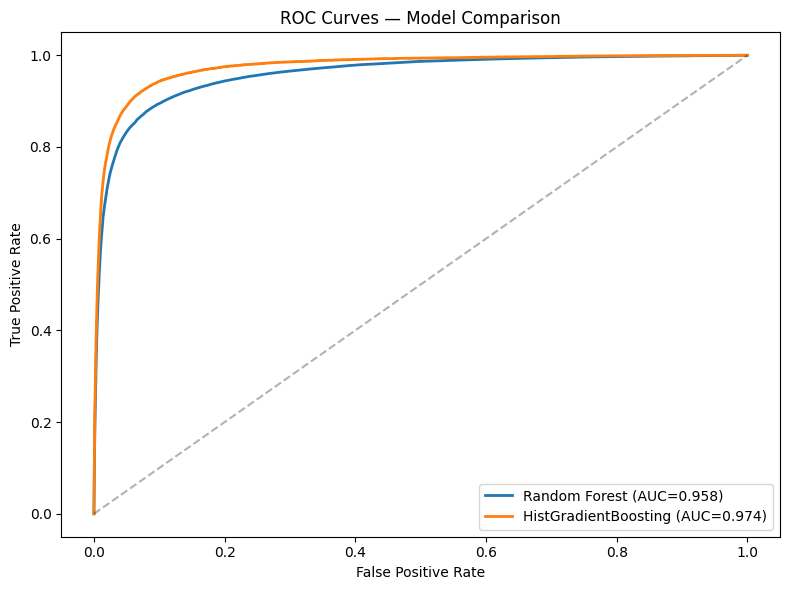


HistGradientBoosting is the stronger model — higher AUC and better default recall.


In [24]:
# ============================================================
# MODEL COMPARISON
# ============================================================

# Summary table
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<25} {'Random Forest':>15} {'HistGradientBoosting':>20}")
print("-" * 60)
print(f"{'Test AUC':<25} {roc_auc_score(y_test, rf_pred_proba):>15.4f} {roc_auc_score(y_test, hgb_pred_proba):>20.4f}")
print(f"{'Precision (default)':<25} {precision_score(y_test, rf_pred):>15.4f} {precision_score(y_test, hgb_pred):>20.4f}")
print(f"{'Recall (default)':<25} {recall_score(y_test, rf_pred):>15.4f} {recall_score(y_test, hgb_pred):>20.4f}")
print(f"{'F1 (default)':<25} {f1_score(y_test, rf_pred):>15.4f} {f1_score(y_test, hgb_pred):>20.4f}")

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
hgb_fpr, hgb_tpr, _ = roc_curve(y_test, hgb_pred_proba)

ax.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_pred_proba):.3f})', linewidth=2)
ax.plot(hgb_fpr, hgb_tpr, label=f'HistGradientBoosting (AUC={roc_auc_score(y_test, hgb_pred_proba):.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nHistGradientBoosting is the stronger model — higher AUC and better default recall.")

In [25]:
# ============================================================
# SAVE PREDICTIONS FOR FAIRNESS AUDIT
# ============================================================
df_test = X_test.copy()
df_test['y_true'] = y_test.values
df_test['rf_pred'] = rf_pred
df_test['rf_pred_proba'] = rf_pred_proba
df_test['hgb_pred'] = hgb_pred
df_test['hgb_pred_proba'] = hgb_pred_proba

print(f"Test predictions saved: {df_test.shape[0]:,} rows")
print(f"\nDemographic coverage in test set:")
print(f"  pct_women_owned non-null: {df_test['pct_women_owned'].notna().sum():,} ({df_test['pct_women_owned'].notna().mean()*100:.1f}%)")
print(f"  pct_minority_owned non-null: {df_test['pct_minority_owned'].notna().sum():,}")

Test predictions saved: 177,330 rows

Demographic coverage in test set:
  pct_women_owned non-null: 95,617 (53.9%)
  pct_minority_owned non-null: 95,617


In [26]:
# ============================================================
# FAIRNESS AUDIT: Define Demographic Subgroups
# ============================================================
# Only use loans that have demographic data
df_fair = df_test[df_test['pct_women_owned'].notna()].copy()
print(f"Loans with demographic data: {df_fair.shape[0]:,}")

# Median split for women-ownership
women_median = df_fair['pct_women_owned'].median()
df_fair['women_group'] = np.where(
    df_fair['pct_women_owned'] >= women_median, 'High Women-Ownership', 'Low Women-Ownership'
)

# Median split for minority-ownership
minority_median = df_fair['pct_minority_owned'].median()
df_fair['minority_group'] = np.where(
    df_fair['pct_minority_owned'] >= minority_median, 'High Minority-Ownership', 'Low Minority-Ownership'
)

print(f"\nWomen-ownership median: {women_median:.3f}")
print(f"  High: {(df_fair['women_group'] == 'High Women-Ownership').sum():,}")
print(f"  Low:  {(df_fair['women_group'] == 'Low Women-Ownership').sum():,}")

print(f"\nMinority-ownership median: {minority_median:.3f}")
print(f"  High: {(df_fair['minority_group'] == 'High Minority-Ownership').sum():,}")
print(f"  Low:  {(df_fair['minority_group'] == 'Low Minority-Ownership').sum():,}")

print(f"\nDefault rates by group:")
print(f"  High Women-Ownership:    {df_fair[df_fair['women_group']=='High Women-Ownership']['y_true'].mean():.3f}")
print(f"  Low Women-Ownership:     {df_fair[df_fair['women_group']=='Low Women-Ownership']['y_true'].mean():.3f}")
print(f"  High Minority-Ownership: {df_fair[df_fair['minority_group']=='High Minority-Ownership']['y_true'].mean():.3f}")
print(f"  Low Minority-Ownership:  {df_fair[df_fair['minority_group']=='Low Minority-Ownership']['y_true'].mean():.3f}")

Loans with demographic data: 95,617

Women-ownership median: 0.205
  High: 48,549
  Low:  47,068

Minority-ownership median: 0.073
  High: 47,810
  Low:  47,807

Default rates by group:
  High Women-Ownership:    0.187
  Low Women-Ownership:     0.211
  High Minority-Ownership: 0.215
  Low Minority-Ownership:  0.182


In [27]:
# ============================================================
# FAIRNESS AUDIT: Compute FPR and FNR by Subgroup
# ============================================================
from sklearn.metrics import confusion_matrix

def compute_fairness_metrics(y_true, y_pred, group_col, df):
    results = []
    for group in sorted(df[group_col].unique()):
        mask = df[group_col] == group
        yt = y_true[mask]
        yp = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()

        fpr = fp / (fp + tn)  # false positive rate
        fnr = fn / (fn + tp)  # false negative rate
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        results.append({
            'Group': group,
            'N': len(yt),
            'Default Rate': yt.mean(),
            'FPR': fpr,
            'FNR': fnr,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall
        })
    return pd.DataFrame(results)

y_true_fair = df_fair['y_true'].values

# ---- HistGradientBoosting (best model) ----
print("=" * 70)
print("HISTGRADIENTBOOSTING — FAIRNESS METRICS")
print("=" * 70)

print("\nBy Women-Ownership:")
hgb_women = compute_fairness_metrics(y_true_fair, df_fair['hgb_pred'].values, 'women_group', df_fair)
print(hgb_women.to_string(index=False))

print("\nBy Minority-Ownership:")
hgb_minority = compute_fairness_metrics(y_true_fair, df_fair['hgb_pred'].values, 'minority_group', df_fair)
print(hgb_minority.to_string(index=False))

# ---- Random Forest ----
print("\n" + "=" * 70)
print("RANDOM FOREST — FAIRNESS METRICS")
print("=" * 70)

print("\nBy Women-Ownership:")
rf_women = compute_fairness_metrics(y_true_fair, df_fair['rf_pred'].values, 'women_group', df_fair)
print(rf_women.to_string(index=False))

print("\nBy Minority-Ownership:")
rf_minority = compute_fairness_metrics(y_true_fair, df_fair['rf_pred'].values, 'minority_group', df_fair)
print(rf_minority.to_string(index=False))

# ---- Disparity Summary ----
print("\n" + "=" * 70)
print("DISPARITY SUMMARY (HistGradientBoosting)")
print("=" * 70)
print(f"\nWomen-Ownership FPR gap:  {abs(hgb_women.iloc[0]['FPR'] - hgb_women.iloc[1]['FPR']):.4f}")
print(f"Women-Ownership FNR gap:  {abs(hgb_women.iloc[0]['FNR'] - hgb_women.iloc[1]['FNR']):.4f}")
print(f"Minority-Ownership FPR gap: {abs(hgb_minority.iloc[0]['FPR'] - hgb_minority.iloc[1]['FPR']):.4f}")
print(f"Minority-Ownership FNR gap: {abs(hgb_minority.iloc[0]['FNR'] - hgb_minority.iloc[1]['FNR']):.4f}")

HISTGRADIENTBOOSTING — FAIRNESS METRICS

By Women-Ownership:
               Group     N  Default Rate      FPR      FNR  Accuracy  Precision   Recall
High Women-Ownership 48549      0.187398 0.027173 0.153330  0.949185   0.877835 0.846670
 Low Women-Ownership 47068      0.210589 0.030224 0.160109  0.942424   0.881139 0.839891

By Minority-Ownership:
                  Group     N  Default Rate      FPR      FNR  Accuracy  Precision   Recall
High Minority-Ownership 47810      0.215269 0.030146 0.146327  0.944844   0.885953 0.853673
 Low Minority-Ownership 47807      0.182358 0.027220 0.169305  0.946870   0.871900 0.830695

RANDOM FOREST — FAIRNESS METRICS

By Women-Ownership:
               Group     N  Default Rate      FPR      FNR  Accuracy  Precision   Recall
High Women-Ownership 48549      0.187398 0.027401 0.220378  0.936435   0.867751 0.779622
 Low Women-Ownership 47068      0.210589 0.029578 0.240920  0.925916   0.872550 0.759080

By Minority-Ownership:
                  Group   

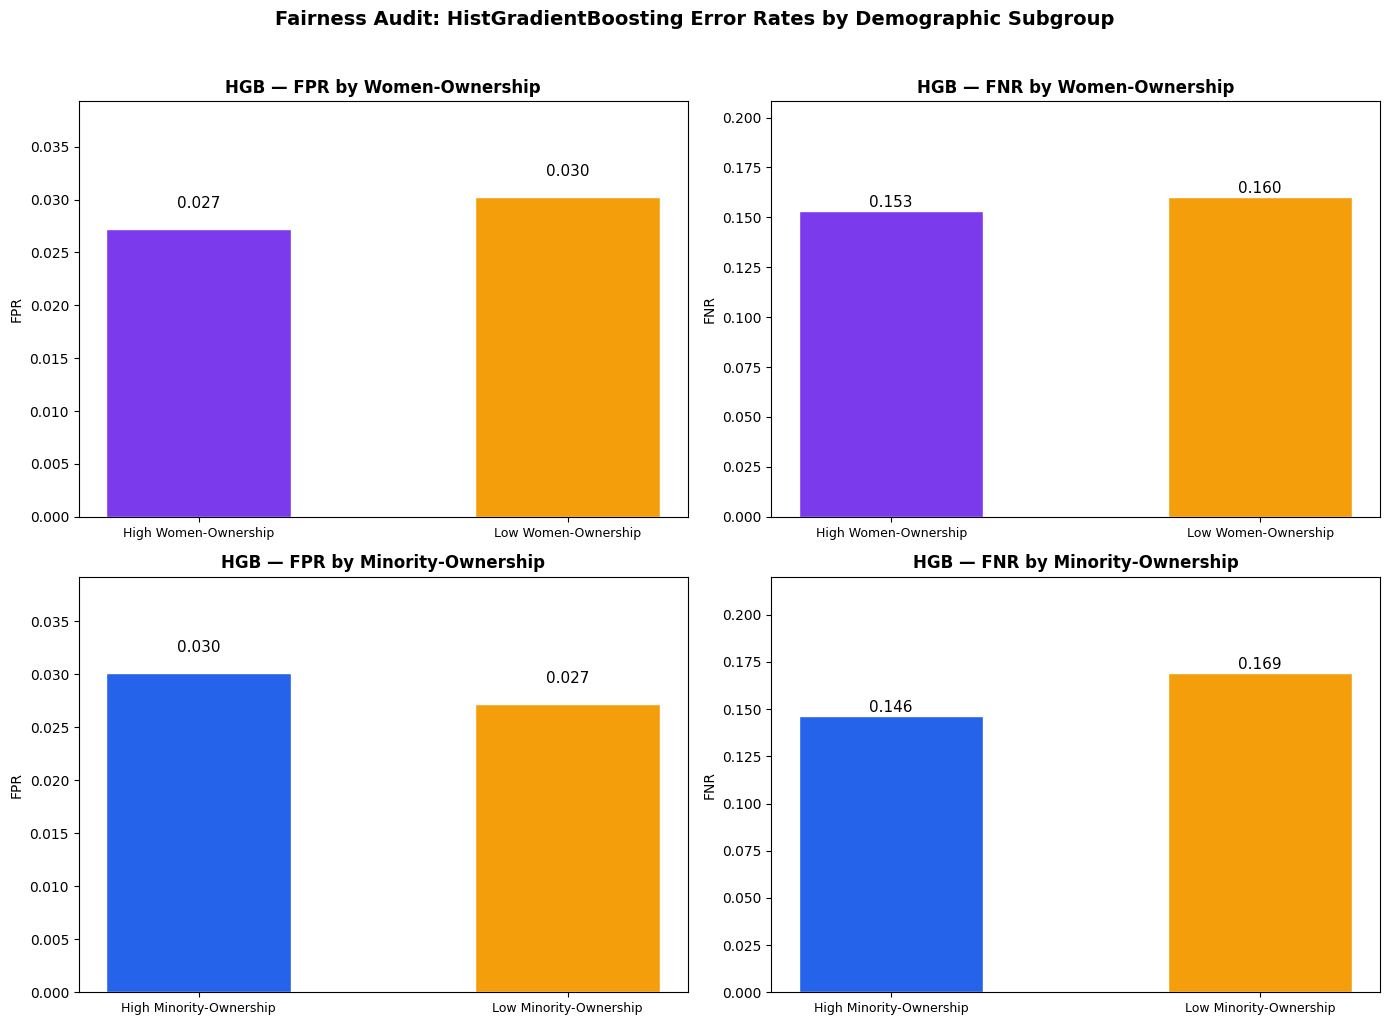


Disparity gaps (closer to 0 = more fair):
  Women FPR gap:    0.0031  ← very small
  Women FNR gap:    0.0068  ← very small
  Minority FPR gap: 0.0029  ← very small
  Minority FNR gap: 0.0230  ← small but largest gap


In [28]:
# ============================================================
# FAIRNESS VISUALIZATION: Disparity Bar Charts
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def plot_disparity(ax, df_metrics, metric, title):
    colors = ['#7C3AED', '#F59E0B'] if 'Women' in df_metrics['Group'].iloc[0] else ['#2563EB', '#F59E0B']
    bars = ax.bar(df_metrics['Group'], df_metrics[metric], color=colors, width=0.5, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, df_metrics[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', fontsize=11)
    ax.set_ylim(0, max(df_metrics[metric]) * 1.3)
    ax.tick_params(axis='x', labelsize=9)

plot_disparity(axes[0, 0], hgb_women, 'FPR', 'HGB — FPR by Women-Ownership')
plot_disparity(axes[0, 1], hgb_women, 'FNR', 'HGB — FNR by Women-Ownership')
plot_disparity(axes[1, 0], hgb_minority, 'FPR', 'HGB — FPR by Minority-Ownership')
plot_disparity(axes[1, 1], hgb_minority, 'FNR', 'HGB — FNR by Minority-Ownership')

fig.suptitle('Fairness Audit: HistGradientBoosting Error Rates by Demographic Subgroup',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Gap summary
print("\nDisparity gaps (closer to 0 = more fair):")
print(f"  Women FPR gap:    {abs(hgb_women.iloc[0]['FPR'] - hgb_women.iloc[1]['FPR']):.4f}  ← very small")
print(f"  Women FNR gap:    {abs(hgb_women.iloc[0]['FNR'] - hgb_women.iloc[1]['FNR']):.4f}  ← very small")
print(f"  Minority FPR gap: {abs(hgb_minority.iloc[0]['FPR'] - hgb_minority.iloc[1]['FPR']):.4f}  ← very small")
print(f"  Minority FNR gap: {abs(hgb_minority.iloc[0]['FNR'] - hgb_minority.iloc[1]['FNR']):.4f}  ← small but largest gap")

Computing permutation importance (this may take a minute)...
Features: 16, Importance array: 16


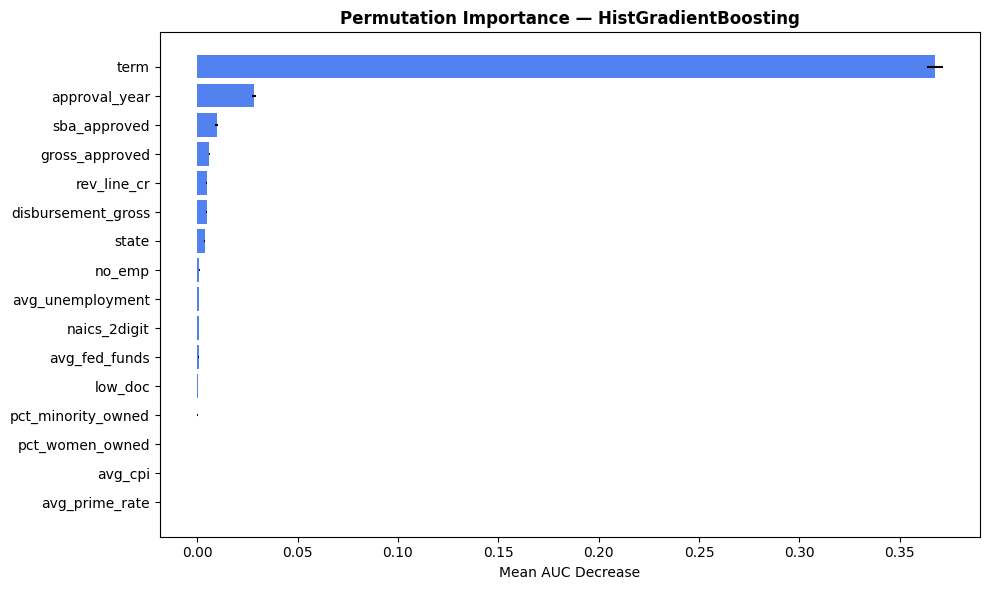


Demographic feature importance:
  pct_women_owned: importance=0.0001 (rank 14/16)
  pct_minority_owned: importance=0.0001 (rank 13/16)


In [31]:
# ============================================================
# MODEL INSPECTION: Permutation Importance
# ============================================================
from sklearn.inspection import permutation_importance

# Use a sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=20000, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

print("Computing permutation importance (this may take a minute)...")
perm_result = permutation_importance(
    hgb_search.best_estimator_, X_sample, y_sample,
    n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

# Feature names = original input columns (not encoded)
feature_names = numeric_features + categorical_features
print(f"Features: {len(feature_names)}, Importance array: {len(perm_result.importances_mean)}")

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_result.importances_mean,
    'std': perm_result.importances_std
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(perm_df)), perm_df['importance'], xerr=perm_df['std'], color='#2563EB', alpha=0.8)
ax.set_yticks(range(len(perm_df)))
ax.set_yticklabels(perm_df['feature'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mean AUC Decrease')
ax.set_title('Permutation Importance — HistGradientBoosting', fontweight='bold')
plt.tight_layout()
plt.show()

# Check demographic features
print("\nDemographic feature importance:")
for feat in ['pct_women_owned', 'pct_minority_owned']:
    row = perm_df[perm_df['feature'] == feat].iloc[0]
    rank = perm_df.index.get_loc(perm_df[perm_df['feature'] == feat].index[0]) + 1
    print(f"  {feat}: importance={row['importance']:.4f} (rank {rank}/{len(perm_df)})")

Computing partial dependence plots (this may take a minute)...


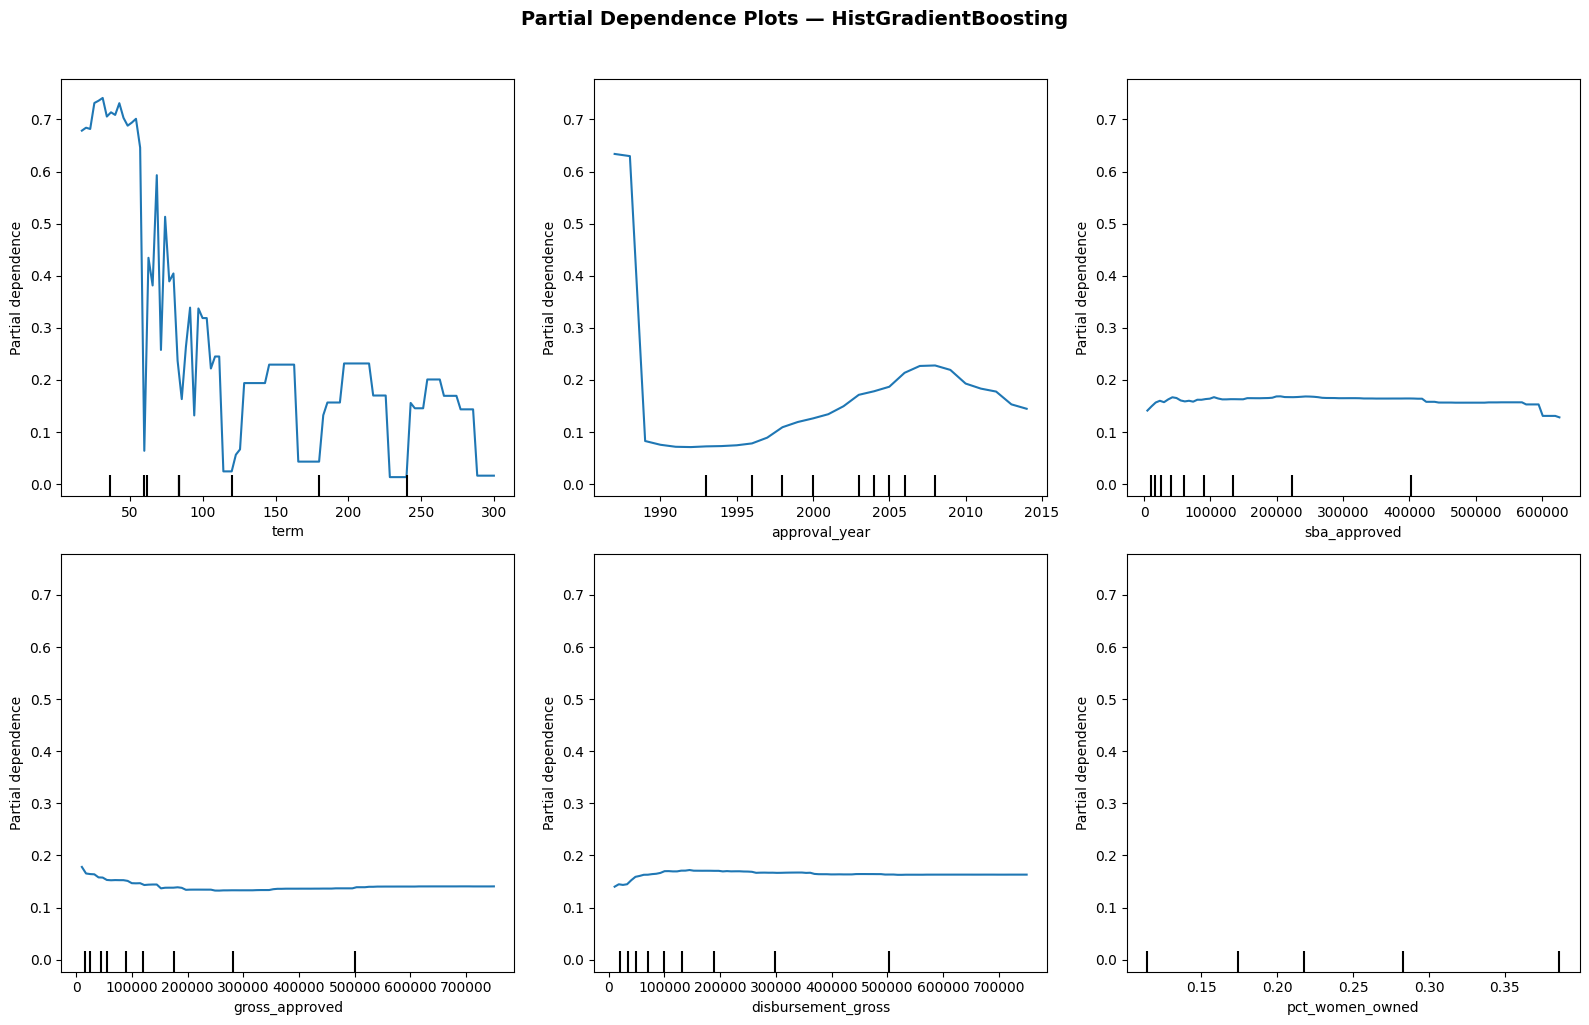


Interpretation guide:
  Y-axis = partial effect on predicted default probability
  Higher = increases predicted default risk
  Lower = decreases predicted default risk


In [32]:
# ============================================================
# MODEL INSPECTION: Partial Dependence Plots
# ============================================================
from sklearn.inspection import PartialDependenceDisplay

# Top 6 features from permutation importance
top_features = ['term', 'approval_year', 'sba_approved', 'gross_approved',
                'disbursement_gross', 'pct_women_owned']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

print("Computing partial dependence plots (this may take a minute)...")
display = PartialDependenceDisplay.from_estimator(
    hgb_search.best_estimator_, X_sample, top_features,
    kind='average', ax=axes.ravel(),
    n_jobs=-1, random_state=42
)

fig.suptitle('Partial Dependence Plots — HistGradientBoosting',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation guide:")
print("  Y-axis = partial effect on predicted default probability")
print("  Higher = increases predicted default risk")
print("  Lower = decreases predicted default risk")